<a href="https://colab.research.google.com/github/oamerciful-rgb/Urban-Mobility-Intelligence-Unit-/blob/main/Big_Data_and_Cloud_Computing_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

8.3 Data Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Load the dataset
df = pd.read_csv("AEP_hourly.csv", parse_dates=["Datetime"])

# Remove duplicate timestamps
df = df.drop_duplicates(subset="Datetime")
df = df.set_index("Datetime").sort_index()

# Force strict hourly index
df = df.asfreq("h")
print("Missing hours:", df["AEP_MW"].isna().sum())

# Fill any gaps
df["AEP_MW"] = df["AEP_MW"].interpolate(limit_direction="both")

# Resample to daily average
daily = df["AEP_MW"].resample("D").mean()
print("Daily series length:", len(daily))

Missing hours: 27
Daily series length: 5055


/tmp/ipykernel_7661/2243730049.py:7: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv("AEP_hourly.csv", parse_dates=["Datetime"])


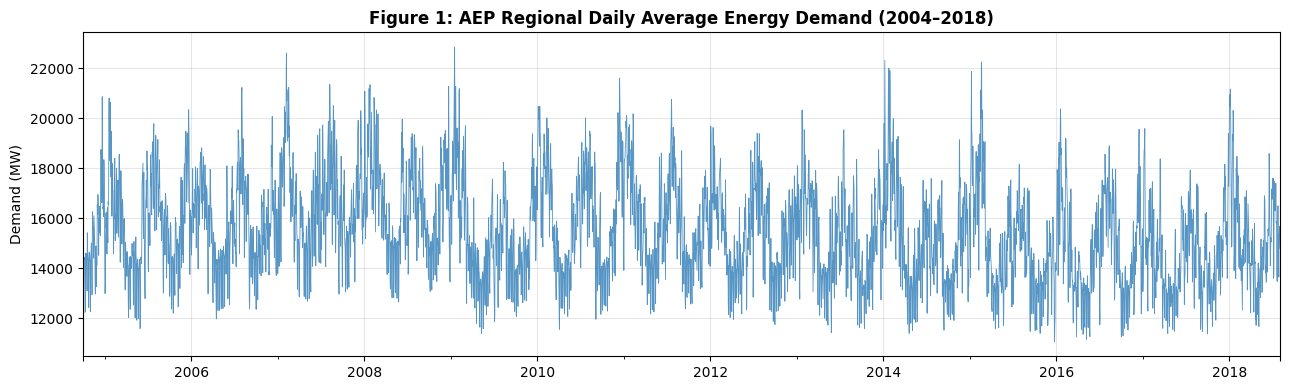

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
daily.plot(ax=ax, color="#2c7bb6", linewidth=0.6, alpha=0.8)
ax.set_title("Figure 1: AEP Regional Daily Average Energy Demand (2004–2018)",
             fontsize=12, fontweight='bold')
ax.set_ylabel("Demand (MW)")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig1_raw_series.png", dpi=150, bbox_inches='tight')
plt.show()

8.4 STL Decomposition

In [ ]:
stl = STL(daily, period=365, robust=True)
result = stl.fit()
print("Decomposition complete.")

Decomposition complete.


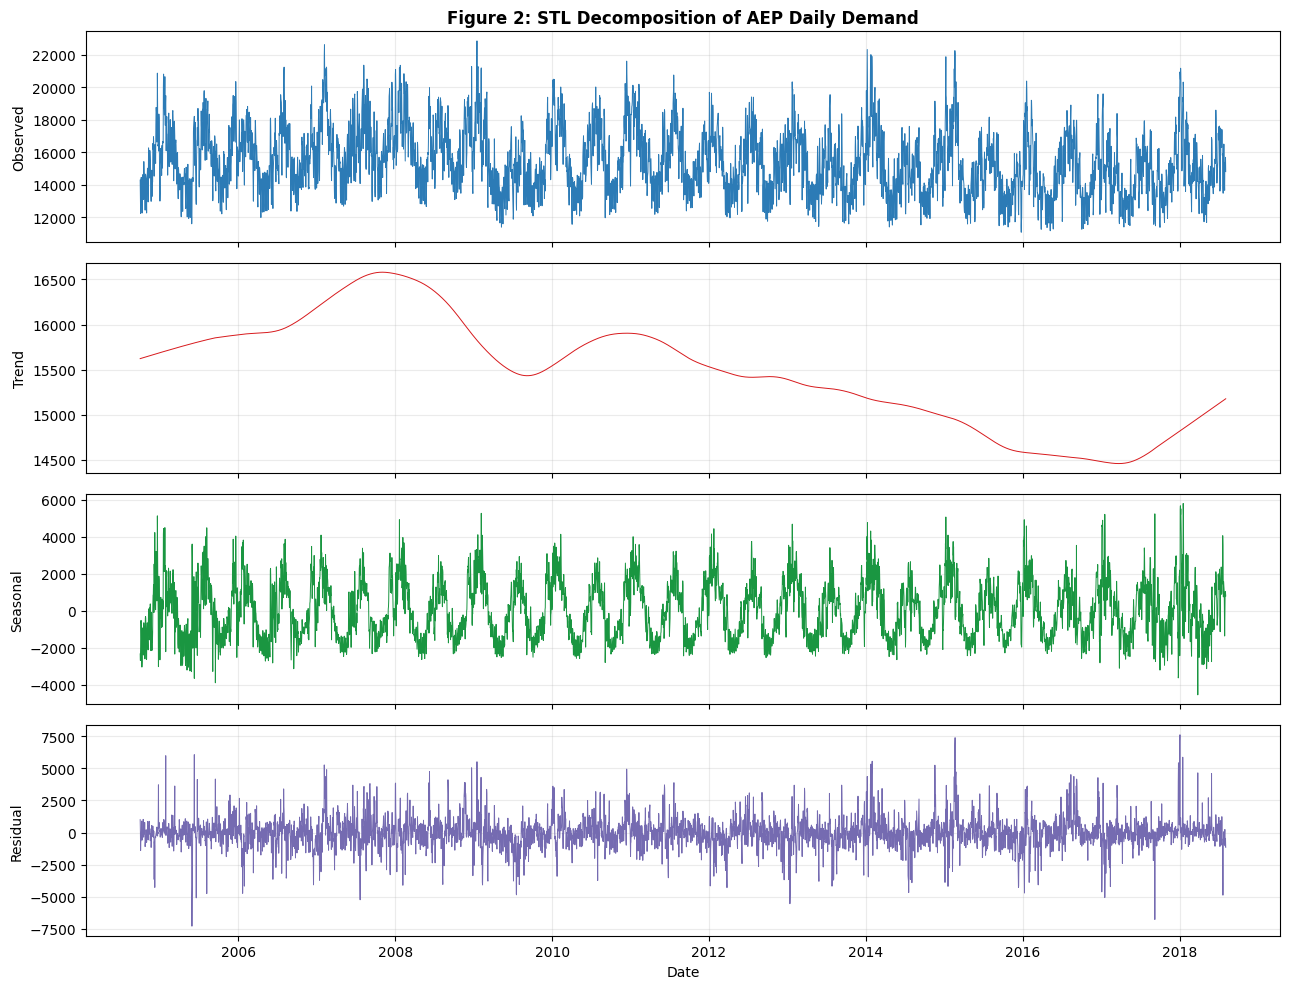

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

components = [
    (daily,           "Observed",  "#2c7bb6"),
    (result.trend,    "Trend",     "#d7191c"),
    (result.seasonal, "Seasonal",  "#1a9641"),
    (result.resid,    "Residual",  "#756bb1"),
]

for ax, (series, label, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, linewidth=0.7)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.25)

axes[0].set_title("Figure 2: STL Decomposition of AEP Daily Demand",
                  fontsize=12, fontweight='bold')
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("fig2_stl_decomposition.png", dpi=150, bbox_inches='tight')
plt.show()

8.5 Seasonal Analysis

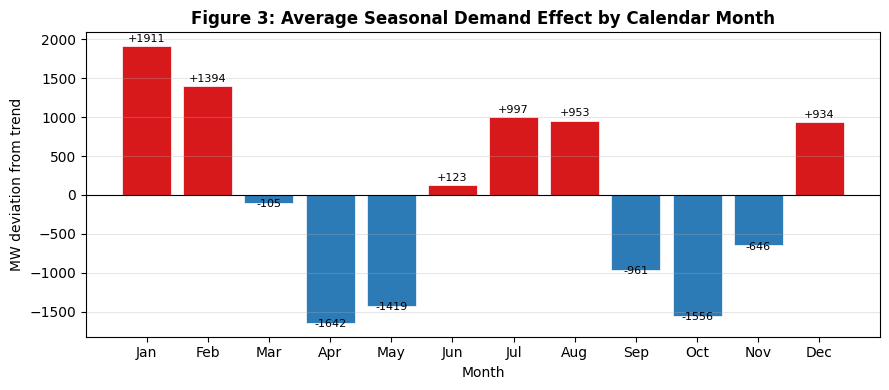

Peak month: Jan
Trough month: Apr


In [ ]:
month_names = {1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
               7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"}

seasonal_by_month = result.seasonal.groupby(result.seasonal.index.month).mean()

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#d7191c" if v > 0 else "#2c7bb6" for v in seasonal_by_month.values]

bars = ax.bar(
    [month_names[int(m)] for m in seasonal_by_month.index],
    seasonal_by_month.values,
    color=colors, edgecolor='white', linewidth=0.5
)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("Figure 3: Average Seasonal Demand Effect by Calendar Month",
             fontsize=12, fontweight='bold')
ax.set_ylabel("MW deviation from trend")
ax.set_xlabel("Month")
ax.grid(True, axis='y', alpha=0.3)

for bar, val in zip(bars, seasonal_by_month.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (30 if val >= 0 else -80),
        f"{val:+.0f}", ha='center', va='bottom', fontsize=8
    )

plt.tight_layout()
plt.savefig("fig3_seasonal_monthly.png", dpi=150, bbox_inches='tight')
plt.show()

peak_month = int(seasonal_by_month.idxmax())
trough_month = int(seasonal_by_month.idxmin())
print(f"Peak month: {month_names[peak_month]}")
print(f"Trough month: {month_names[trough_month]}")

8.6 Naive Seasonal Projection

In [ ]:
HORIZON = 365

recent_trend = result.trend.dropna().iloc[-730:]
x = np.arange(len(recent_trend))
slope, intercept = np.polyfit(x, recent_trend.values, 1)

future_x     = np.arange(len(recent_trend), len(recent_trend) + HORIZON)
future_trend = slope * future_x + intercept

future_seasonal = result.seasonal.iloc[-365:].values[:HORIZON]

future_index = pd.date_range(
    daily.index[-1] + pd.Timedelta(days=1),
    periods=HORIZON, freq="D"
)
projection = pd.Series(future_trend + future_seasonal, index=future_index)
print(f"Projected range: {projection.min():.0f} – {projection.max():.0f} MW")
print(f"Projected mean: {projection.mean():.0f} MW")

Projected range: 10715 – 20999 MW
Projected mean: 15220 MW


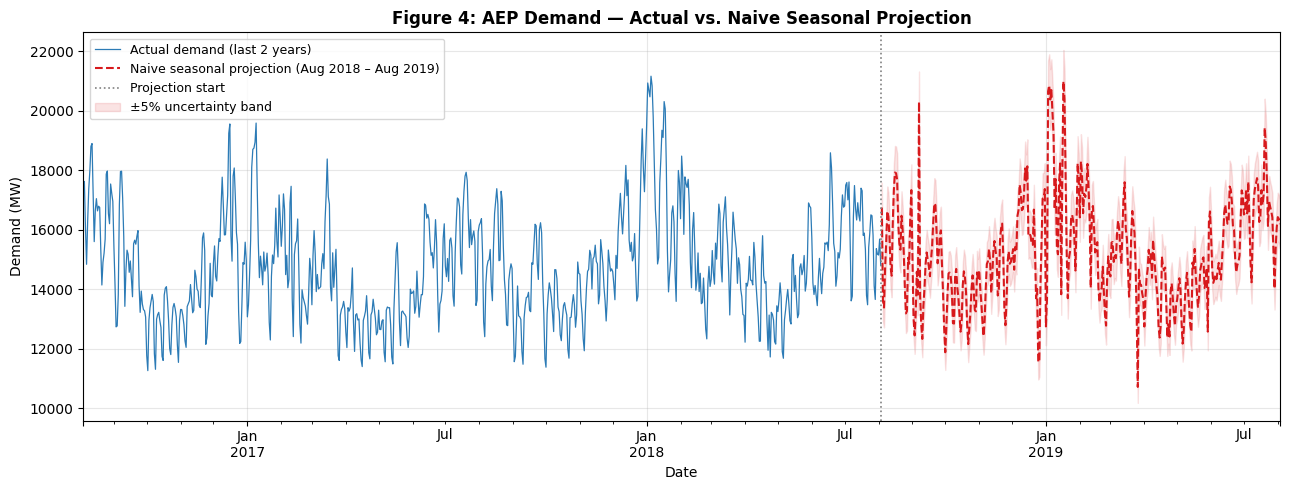

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

daily.iloc[-730:].plot(
    ax=ax, color="#2c7bb6", linewidth=0.9,
    label="Actual demand (last 2 years)"
)

projection.plot(
    ax=ax, color="#d7191c", linewidth=1.5, linestyle="--",
    label="Naive seasonal projection (Aug 2018 – Aug 2019)"
)

ax.axvline(daily.index[-1], color='grey', linestyle=':', linewidth=1.2,
           label="Projection start")

ax.fill_between(
    projection.index,
    projection.values * 0.95,
    projection.values * 1.05,
    color="#d7191c", alpha=0.12, label="±5% uncertainty band"
)

ax.set_title("Figure 4: AEP Demand — Actual vs. Naive Seasonal Projection",
             fontsize=12, fontweight='bold')
ax.set_ylabel("Demand (MW)")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig4_projection.png", dpi=150, bbox_inches='tight')
plt.show()